<h3>Dataset Overview</h3>
<p>This dataset contains AI-related job postings in India collected between 2024 and 2026. It includes information about job roles, salaries, experience requirements, locations, companies, industries, work modes, applicants, ratings, and posting dates.</p>
<p>The dataset will be used for:</p>
<ul>
<li> Exploratory Data Analysis (EDA)</li>
<li>Feature Engineering</li>
<li>Time Series Forecasting</li>
<li>Machine Learning</li>
<li>Business Intelligence Dashboard</li></ul>

In [1]:
## Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load dataset
df = pd.read_csv("Ai_job_market.csv")
df.head()

,Job_ID,Job_Title,Company,Company_Type,Industry,City,Location_Tier,Experience_Level,Job_Type,Work_Mode,Salary_LPA,Skills_Required,Education_Required,Openings,Applicants,Company_Rating,Date_Posted
0,IND2025000,Android Developer,Tech Mahindra,MNC,Information Technology,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,30.9,"Kotlin, Java, REST APIs",M.Tech/M.E.,3,276,4.0,2025-10-31
1,IND2025001,QA Engineer,Dream11,Indian Unicorn,Information Technology,Lucknow,Tier 2,Senior (6-10 yrs),Full-Time,Hybrid,58.6,"Selenium, Manual Testing, Postman, API Testing...",B.Tech/B.E.,3,325,4.0,2025-05-19
2,IND2025002,Business Analyst,HAL,PSU/Govt,EdTech,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,18.4,"JIRA, Excel, Power BI",MCA,5,559,3.6,2024-08-21
3,IND2025003,Cybersecurity Analyst,Groww,Startup,Information Technology,Mumbai,Tier 1,Mid (3-6 yrs),Full-Time,Hybrid,21.7,"Penetration Testing, Python, Ethical Hacking, ...",BCA,3,184,3.5,2026-03-18
4,IND2025004,Python Developer,Oracle,MNC,EdTech,Remote,Remote,Junior (1-3 yrs),Full-Time,Remote,8.0,"Docker, REST APIs, AWS, PostgreSQL",MCA,1,64,3.9,2024-10-25


In [3]:
#Check for rows and columns
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 5000
Columns : 17


In [4]:
#checking dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Job_ID              5000 non-null   object 
 1   Job_Title           5000 non-null   object 
 2   Company             5000 non-null   object 
 3   Company_Type        5000 non-null   object 
 4   Industry            5000 non-null   object 
 5   City                5000 non-null   object 
 6   Location_Tier       5000 non-null   object 
 7   Experience_Level    5000 non-null   object 
 8   Job_Type            5000 non-null   object 
 9   Work_Mode           5000 non-null   object 
 10  Salary_LPA          5000 non-null   float64
 11  Skills_Required     5000 non-null   object 
 12  Education_Required  5000 non-null   object 
 13  Openings            5000 non-null   int64  
 14  Applicants          5000 non-null   int64  
 15  Company_Rating      5000 non-null   float64
 16  Date_P

In [5]:
#checking for null values
df.isnull().sum()

Job_ID                0
Job_Title             0
Company               0
Company_Type          0
Industry              0
City                  0
Location_Tier         0
Experience_Level      0
Job_Type              0
Work_Mode             0
Salary_LPA            0
Skills_Required       0
Education_Required    0
Openings              0
Applicants            0
Company_Rating        0
Date_Posted           0
dtype: int64

In [6]:
#checking the information for numerical columns
df.describe()

,Salary_LPA,Openings,Applicants,Company_Rating
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,19.829440,3.642600,302.072000,3.698420
std,18.136741,4.046942,363.989613,0.424994
min,0.800000,1.000000,14.000000,2.500000
25%,6.800000,1.000000,99.000000,3.400000
50%,13.600000,2.000000,185.000000,3.800000
75%,25.600000,3.000000,321.000000,4.100000
max,115.400000,20.000000,2387.000000,4.300000


In [7]:
#checking information for categorical column
df.describe(include='object')

,Job_ID,Job_Title,Company,Company_Type,Industry,City,Location_Tier,Experience_Level,Job_Type,Work_Mode,Skills_Required,Education_Required,Date_Posted
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000
unique,5000,30,53,4,15,17,3,5,4,3,4817,8,697
top,IND2025000,Software Engineer,Wipro,MNC,Information Technology,Remote,Tier 1,Mid (3-6 yrs),Full-Time,On-Site,"Next.js, JavaScript, React",B.Tech/B.E.,2025-10-06
freq,1,336,134,1717,1545,1992,2086,1378,3648,2005,3,2000,16


In [8]:
#checking for duplicates
df.duplicated().sum()

0

In [9]:
#checking for each feature datatype
df.dtypes

Job_ID                 object
Job_Title              object
Company                object
Company_Type           object
Industry               object
City                   object
Location_Tier          object
Experience_Level       object
Job_Type               object
Work_Mode              object
Salary_LPA            float64
Skills_Required        object
Education_Required     object
Openings                int64
Applicants              int64
Company_Rating        float64
Date_Posted            object
dtype: object

In [10]:
#the date_posted should be 'date_time' datatype 
df['Date_Posted'] = pd.to_datetime(df['Date_Posted'])

In [11]:
#finding the date range for job posted
print(df['Date_Posted'].min())
print(df['Date_Posted'].max())
date_range = df['Date_Posted'].max() - df['Date_Posted'].min()
print(date_range)

2024-06-01 00:00:00
2026-04-30 00:00:00
698 days 00:00:00


In [12]:
#checking for any missing monthly value
monthly_jobs = (df.groupby(df['Date_Posted'].dt.to_period('M')).size())
monthly_jobs

Date_Posted
2024-06    215
2024-07    202
2024-08    222
2024-09    224
2024-10    239
2024-11    222
2024-12    198
2025-01    220
2025-02    192
2025-03    236
2025-04    216
2025-05    213
2025-06    219
2025-07    231
2025-08    211
2025-09    234
2025-10    233
2025-11    196
2025-12    228
2026-01    201
2026-02    207
2026-03    220
2026-04    221
Freq: M, dtype: int64

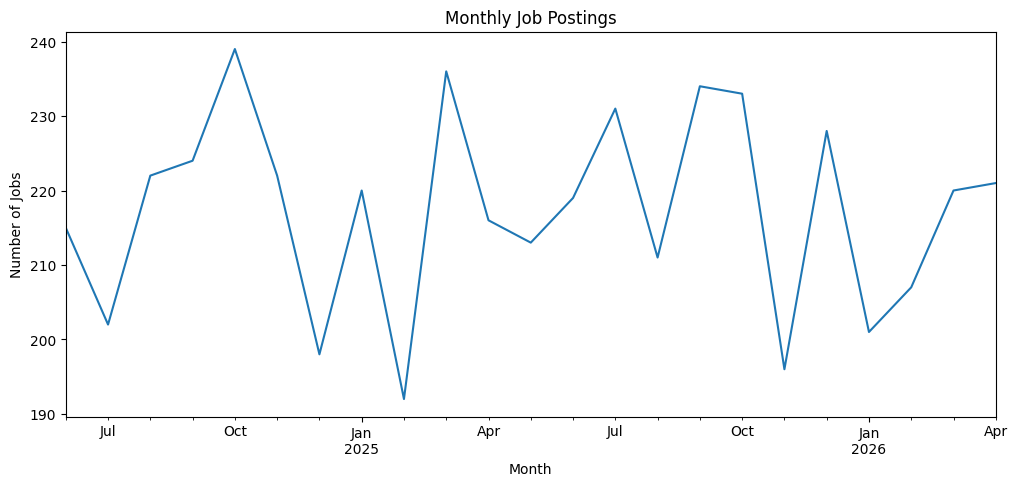

In [13]:
#monthly job trend in graph
monthly_jobs.plot(figsize=(12,5))
plt.title("Monthly Job Postings")
plt.xlabel("Month")
plt.ylabel("Number of Jobs")
plt.show()

<h4>Summary</h4>
<p>Key findings from Data Understanding phase:</p>
<ul>
    <li>The dataset contains 5,000 AI job postings.</li>
    <li>It includes 17 attributes describing jobs, salaries, companies, skills, and applicants.</li>
    <li>The data spans June 2024 to April 2026.</li>
    <li>Data types have been identified for all features.</li>
    <li>Missing values and duplicate records have been assessed.</li>
    <li>Monthly job posting trends indicate that the dataset is appropriate for time series forecasting.</li>
</ul>

<h3>Notebook 2: Data Cleaning</h3>
<b>Objective</b>
<p>The objective of this notebook is to improve the quality of the dataset by identifying and handling any inconsistencies, duplicate records, missing values, incorrect data types, and potential outliers. A clean dataset ensures accurate exploratory analysis and reliable forecasting results.</p>

<p> As the data is already clean</p>

In [14]:
#checking unique categorical features
categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    print("="*60)
    print(col)
    print(df[col].unique())

Job_ID
['IND2025000' 'IND2025001' 'IND2025002' ... 'IND2029997' 'IND2029998'
 'IND2029999']
Job_Title
['Android Developer' 'QA Engineer' 'Business Analyst'
 'Cybersecurity Analyst' 'Python Developer' 'Backend Developer'
 'Power BI Developer' 'Java Developer' 'Technical Lead' 'UI/UX Designer'
 'Data Analyst' 'Software Engineer' 'Machine Learning Engineer'
 'Data Engineer' 'Node.js Developer' 'Computer Vision Engineer'
 'MLOps Engineer' 'DevOps Engineer' 'Product Manager' 'Frontend Developer'
 'Full Stack Developer' 'Cloud Engineer' 'React Developer'
 'Blockchain Developer' 'AI Engineer' 'Research Scientist' 'iOS Developer'
 'NLP Engineer' 'Data Scientist' 'Engineering Manager']
Company
['Tech Mahindra' 'Dream11' 'HAL' 'Groww' 'Oracle' 'Nykaa' 'PhonePe'
 'Cisco' 'HCL Technologies' 'Chargebee' 'Infosys' 'Hasura' 'ISRO' 'Google'
 'BHEL' 'Cognizant' 'BrowserStack' 'Setu' 'BSNL' 'CRED' "Byju's"
 'Lenskart' 'Khatabook' 'Wipro' 'Razorpay' 'Deloitte' 'Accenture'
 'Urban Company' 'Zoho' 'Leadsqu

In [15]:
#checking for numerical summary
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Salary_LPA,5000.0,19.82944,0.8,6.8,13.6,25.6,115.4,18.136741
Openings,5000.0,3.6426,1.0,1.0,2.0,3.0,20.0,4.046942
Applicants,5000.0,302.072,14.0,99.0,185.0,321.0,2387.0,363.989613
Company_Rating,5000.0,3.69842,2.5,3.4,3.8,4.1,4.3,0.424994
Date_Posted,5000,2025-05-16 11:47:54.240000,2024-06-01 00:00:00,2024-11-19 18:00:00,2025-05-16 00:00:00,2025-11-03 06:00:00,2026-04-30 00:00:00,NaN


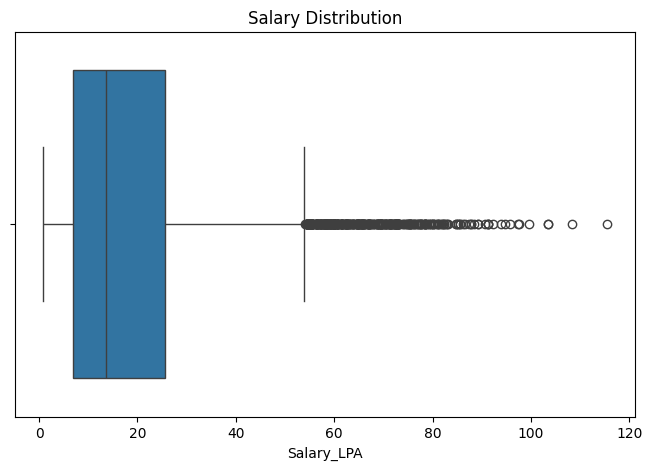

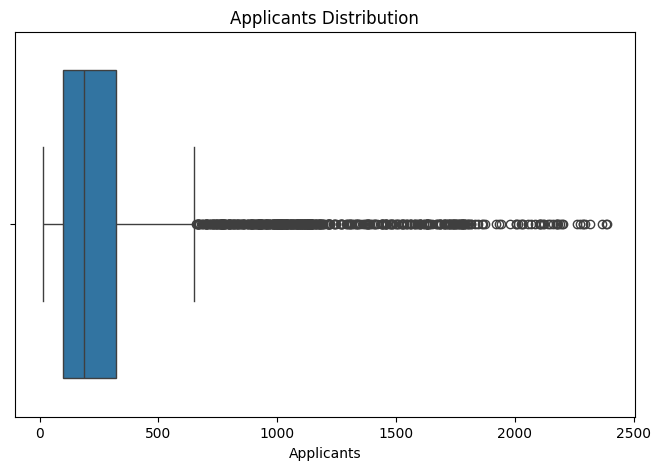

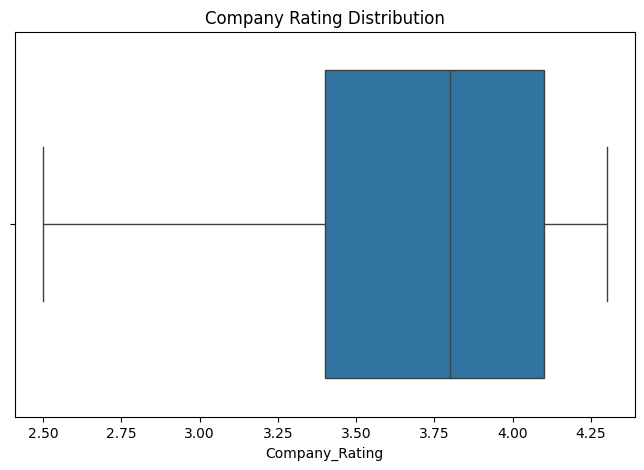

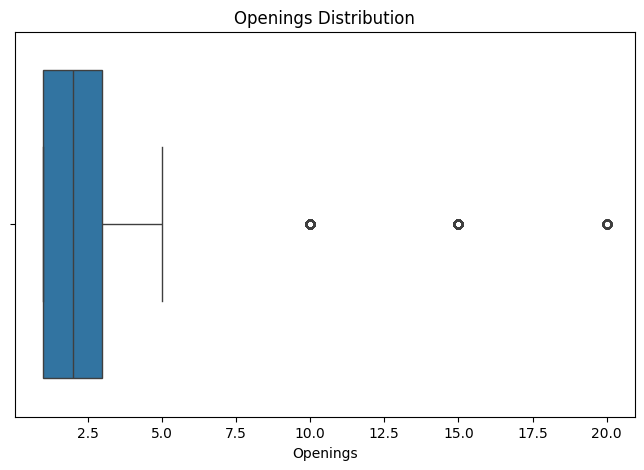

In [16]:
#outlier detection
# salary
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Salary_LPA"])
plt.title("Salary Distribution")
plt.show()
#Applicants
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Applicants"])
plt.title("Applicants Distribution")
plt.show()
#company rating
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Company_Rating"])
plt.title("Company Rating Distribution")
plt.show()
#opening
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Openings"])
plt.title("Openings Distribution")
plt.show()

<h4>Summary</h4>
<p>The data cleaning process confirmed that the dataset is of high quality</p>
<p>Key Observations:</p>
<ul>
    <li>No missing values were found</li>
    <li>No duplicate records were detected</li>
    <li>The 'Date_Posted' column was converted to datetime format</li>
    <li>Numerical and Categorical variables were verified</li>
    <li> Potential outliers were identified but retained because they likely represent genuine market behaviour </li>
</ul>
<p> The clean dataset is now ready for exploratory data analysis (EDA).</p>

<h4> Notebook 3: Basic Feature Engineering</h4>
<b>Objective:</b>
<p>The objective of this notebook is to transform existing variables into more informative features that improve EDA and prepare the dataset for predictive modelling. These engineered features capture temporal patterns, categorize numerical values, and quantify job characteristics. </p>

In [17]:
#creating features
# Year
df['Year'] = df['Date_Posted'].dt.year

# Month Number
df['Month'] = df['Date_Posted'].dt.month

# Month Name
df['Month_Name'] = df['Date_Posted'].dt.month_name()

# Quarter
df['Quarter'] = df['Date_Posted'].dt.quarter

# Week Number
df['Week'] = df['Date_Posted'].dt.isocalendar().week.astype(int)

# Day
df['Day'] = df['Date_Posted'].dt.day

# Day Name
df['Day_Name'] = df['Date_Posted'].dt.day_name()

# Weekend Flag
df['Weekend_Posting'] = df['Day_Name'].isin(['Saturday', 'Sunday'])

In [18]:
#salary category
salary_bins = [0, 5, 15, 30, float('inf')]
salary_labels = [
    'Low',
    'Medium',
    'High',
    'Premium'
]
df['Salary_Category'] = pd.cut(df['Salary_LPA'],bins=salary_bins,labels=salary_labels, include_lowest=True)

In [19]:
df['Experience_Level'].value_counts()

Experience_Level
Mid (3-6 yrs)        1378
Junior (1-3 yrs)     1256
Fresher (0-1 yr)     1022
Senior (6-10 yrs)     831
Lead (10+ yrs)        513
Name: count, dtype: int64

In [20]:
#Experience encoding
experience_mapping = {
    'Fresher (0-1 yr)': 0,
    'Junior (1-3 yrs)': 1,
    'Mid (3-6 yrs)': 2,
    'Senior (6-10 yrs)': 3,
    'Lead (10+ yrs)': 4
}

df['Experience_Level_Encoded'] = (
    df['Experience_Level'].map(experience_mapping)
)

In [21]:
#company rating category
rating_bins = [0,3,4,5]
rating_labels = [
    'Low Rated',
    'Average',
    'Highly Rated'
]
df['Rating_Category'] = pd.cut(df['Company_Rating'],bins=rating_bins,labels=rating_labels, include_lowest=True)

In [22]:
#applicant competition
df['Applicant_Category'] = pd.qcut(df['Applicants'],q=3,labels=[
        'Low Competition',
        'Medium Competition',
        'High Competition'])

In [23]:
#hiring size
df['Hiring_Size'] = pd.cut(df['Openings'],bins=[0,3,7,20],labels=[
        'Small Hiring',
        'Medium Hiring',
        'Mass Hiring'], include_lowest= True)

In [24]:
#skill count
df['Skill_Count'] = (df['Skills_Required'].str.split(',').str.len())

In [25]:
#Verifying the new features
new_features = [
    'Year',
    'Month',
    'Month_Name',
    'Quarter',
    'Day',
    'Day_Name',
    'Week',
    'Weekend_Posting',
    'Salary_Category',
    'Experience_Level_Encoded',
    'Rating_Category',
    'Applicant_Category',
    'Hiring_Size',
    'Skill_Count'
]

df[new_features].head()

,Year,Month,Month_Name,Quarter,Day,Day_Name,Week,Weekend_Posting,Salary_Category,Experience_Level_Encoded,Rating_Category,Applicant_Category,Hiring_Size,Skill_Count
0,2025,10,October,4,31,Friday,44,False,Premium,3,Average,High Competition,Small Hiring,3
1,2025,5,May,2,19,Monday,21,False,Premium,3,Average,High Competition,Small Hiring,5
2,2024,8,August,3,21,Wednesday,34,False,High,3,Average,High Competition,Medium Hiring,3
3,2026,3,March,1,18,Wednesday,12,False,High,2,Average,Medium Competition,Small Hiring,5
4,2024,10,October,4,25,Friday,43,False,Medium,1,Average,Low Competition,Small Hiring,4


<h4>Summary</h4>
<p>In this notebook, several informative features were created to enhance both exploratory data analysis and predictive modeling.</p>
<p>The newly engineered features include:</p>
<ul>
    <li>Date-based attributes (year, month, quarter,week ,day)</li>
    <li>Salary Categories</li>
    <li>Encoded experience levels</li>
    <li>Comapny rating categories</li>
    <li>Applicant competition levels</li>
    <li>Hiring size categories</li>
    <li>skill count</li>
</ul>
<p>These features provide additional insights into hiring patterns and will support both visualization and forecasting tasks in the subsequent notebooks.</p>

In [26]:
df.to_csv("Cleaned_engineered_jobdata.csv",index=False)

In [27]:
print(df.columns.tolist())

['Job_ID', 'Job_Title', 'Company', 'Company_Type', 'Industry', 'City', 'Location_Tier', 'Experience_Level', 'Job_Type', 'Work_Mode', 'Salary_LPA', 'Skills_Required', 'Education_Required', 'Openings', 'Applicants', 'Company_Rating', 'Date_Posted', 'Year', 'Month', 'Month_Name', 'Quarter', 'Week', 'Day', 'Day_Name', 'Weekend_Posting', 'Salary_Category', 'Experience_Level_Encoded', 'Rating_Category', 'Applicant_Category', 'Hiring_Size', 'Skill_Count']


In [28]:
df = pd.read_csv("Cleaned_engineered_jobdata.csv")

print(df.columns.tolist())


['Job_ID', 'Job_Title', 'Company', 'Company_Type', 'Industry', 'City', 'Location_Tier', 'Experience_Level', 'Job_Type', 'Work_Mode', 'Salary_LPA', 'Skills_Required', 'Education_Required', 'Openings', 'Applicants', 'Company_Rating', 'Date_Posted', 'Year', 'Month', 'Month_Name', 'Quarter', 'Week', 'Day', 'Day_Name', 'Weekend_Posting', 'Salary_Category', 'Experience_Level_Encoded', 'Rating_Category', 'Applicant_Category', 'Hiring_Size', 'Skill_Count']
